# 🔥 Stage 2: Supervised Learning on Balanced Dataset

**Objective:** Fine-tune RoBERTa on the Kaggle Game Dataset (balanced via undersampling) to evaluate performance when class imbalance is removed.

**Dataset:** Kaggle Reddit Gaming Comments (~23k samples – balanced via undersampling)

**Method:** Standard CrossEntropy Loss on a balanced dataset

---

## 📊 Pipeline

1. Load Kaggle dataset (CSV upload to Colab)
2. Balance dataset using **undersampling** (equal samples per class)
3. Encode labels (`positive`, `neutral`, `negative`) → integers
4. Tokenize text using `AutoTokenizer` (RoBERTa-Twitter)
5. Fine-tune RoBERTa-Twitter using **HuggingFace Trainer**
6. Evaluate on test set (Accuracy, Weighted F1, Macro F1, Confusion Matrix)

---

## 🎯 Key Highlights

- Removes class imbalance by undersampling → all classes have equal representation  
- Standard CrossEntropy Loss for stable training  
- Baseline to compare against Stage 3 techniques (Focal Loss / Class Weighting)  




# Environment Setup


In [1]:
# Install core NLP libraries (Transformers, Datasets, Accelerate, SentencePiece)
!pip install -q "transformers>=4.42.0" "datasets>=2.20.0" "accelerate>=0.30.0" sentencepiece

# Install data processing & evaluation libraries
!pip install -q pandas numpy scikit-learn

# Install visualization tools
!pip install -q matplotlib seaborn

# Install wandb only to avoid auto-login errors (we won't use tracking)
!pip install -q wandb



# Import Libraries


In [2]:

# Ignore warnings to keep notebook output clean
import warnings
warnings.filterwarnings('ignore')

# JSON & Colab file utilities
import json
from google.colab import files

# Base libraries
import re
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Disable wandb (avoid auto-login errors in Colab/Kaggle)
import wandb
wandb.init(mode="disabled")

# Progress bar
from tqdm.auto import tqdm

# HuggingFace: Dataset handling
from datasets import Dataset

# Suppress transformers logging (cleaner output)
from transformers.utils import logging
logging.set_verbosity_error()

# Sklearn: split & metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

# HuggingFace training modules
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

# Plot style settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Environment check
print("Environment Loaded | GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


Environment Loaded | GPU: Tesla T4


# Load Dataset from Local (Upload to Colab)



In [3]:

print("Upload Kaggle CSV file from your computer")
uploaded = files.upload()  # user selects file manually

# Get uploaded filename
csv_filename = list(uploaded.keys())[0]

# Read CSV into DataFrame
df = pd.read_csv(csv_filename)
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Preview first rows
print("\nPreview dataframe:")
display(df.head())

# Check label distribution
print("\nLabel distribution:")
print(df['sentiment'].value_counts())


Upload Kaggle CSV file from your computer


Saving cleaned_comments.csv to cleaned_comments.csv

Preview dataframe:


,comment,sentiment
0,dont think like game havent even played minute...,negative
1,leave farm smaller creature either wait help k...,negative
2,nothing beat feeling get see fall love like ye...,positive
3,also theyre made paper edit tried make gif fai...,negative
4,haha exactly brother tried get wow run raid ge...,positive



Label distribution:
sentiment
positive    9777
neutral     8013
negative    4031
Name: count, dtype: int64


# Balance dataset (Undersampling)

In [4]:
label_col = "sentiment"
text_col = "comment"

# Ensure comment, label is string (e.g., "positive", "neutral", "negative")
df[label_col] = df[label_col].astype(str)
df[text_col] = df[text_col].astype(str)


print("Original label distribution:")
print(df[label_col].value_counts(), "\n")

# Get min samples per class
class_counts = df[label_col].value_counts()
min_count = class_counts.min()

# Undersample each class to match smallest group
balanced_df = df.groupby(label_col).apply(
    lambda x: x.sample(min_count, random_state=42)
).reset_index(drop=True)

print("Balanced dataset distribution (undersampling):")
print(balanced_df[label_col].value_counts())

Original label distribution:
sentiment
positive    9777
neutral     8013
negative    4031
Name: count, dtype: int64 

Balanced dataset distribution (undersampling):
sentiment
negative    4031
neutral     4031
positive    4031
Name: count, dtype: int64


#Train/Val/Test Split

In [5]:
train_df, temp_df = train_test_split(
    balanced_df, test_size=0.3, stratify=balanced_df[label_col], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df[label_col], random_state=42
)

print(train_df["comment"].dtype)
print("📊 Dataset Split Summary")
print("-" * 50)
print(f"🟩 Training set:      {len(train_df):,} samples")
print(f"🟦 Validation set:    {len(val_df):,} samples")
print(f"🟥 Test set:          {len(test_df):,} samples")
print("-" * 50)
print(f"✅ Total:             {len(train_df) + len(val_df) + len(test_df):,} samples")
print(f"📎 Columns: {list(df.columns)}")

object
📊 Dataset Split Summary
--------------------------------------------------
🟩 Training set:      8,465 samples
🟦 Validation set:    1,814 samples
🟥 Test set:          1,814 samples
--------------------------------------------------
✅ Total:             12,093 samples
📎 Columns: ['comment', 'sentiment']


#Tokenizer + Label Encoding


In [6]:
MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)

# Check token lengths
comment_lengths = df[text_col].apply(lambda x: len(tokenizer.tokenize(x)))
print("Mean token length:", comment_lengths.mean())
print("Max token length:", comment_lengths.max())
pct_long = (comment_lengths > 128).mean() * 100
print(f"{pct_long:.2f}% comments longer than 128 tokens")

# Ensure labels are string
df[label_col] = df[label_col].astype(str)

# Create label2id / id2label mapping
label2id = {label: i for i, label in enumerate(sorted(df[label_col].unique()))}
id2label = {v: k for k, v in label2id.items()}

print("Label mapping:", label2id)

# Apply numerical labels for HF training
train_df["label"] = train_df[label_col].map(label2id)
val_df["label"]   = val_df[label_col].map(label2id)
test_df["label"]  = test_df[label_col].map(label2id)

# Tokenizer function
def tokenize(example):
    return tokenizer(
        example[text_col],
        truncation=True,
        padding="max_length",
        max_length=512
    )

# Convert to HF datasets
train_data = Dataset.from_pandas(train_df[["label", text_col]]).map(tokenize, batched=True)
val_data   = Dataset.from_pandas(val_df[["label", text_col]]).map(tokenize, batched=True)
test_data  = Dataset.from_pandas(test_df[["label", text_col]]).map(tokenize, batched=True)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Mean token length: 12.8033545667018
Max token length: 1299
0.35% comments longer than 128 tokens
Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


Map:   0%|          | 0/8465 [00:00<?, ? examples/s]

Map:   0%|          | 0/1814 [00:00<?, ? examples/s]

Map:   0%|          | 0/1814 [00:00<?, ? examples/s]

#Create & Configure Model

In [7]:
def compute_metrics(p):
    """
    Computes accuracy, weighted F1, and macro F1 for classification.
    """
    predictions = np.argmax(p.predictions, axis=1)
    labels = p.label_ids

    acc = accuracy_score(labels, predictions)
    f1_weighted = f1_score(labels, predictions, average='weighted')
    f1_macro    = f1_score(labels, predictions, average='macro')

    return {
        'accuracy': acc,
        'f1': f1_weighted,
        'f1_weighted': f1_weighted,
        'f1_macro': f1_macro
    }


In [8]:
# Load pre-trained RoBERTa for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
).to('cuda')

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    num_train_epochs= 3,
    per_device_train_batch_size= 16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_steps=500,
    weight_decay=0.05,
    logging_dir='./logs',
    logging_steps=50,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    max_grad_norm=1.0

)

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

#Initialize Trainer & Start Training

In [9]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    data_collator=DataCollatorWithPadding(tokenizer),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    compute_metrics=compute_metrics
)

# Print training info
print("="*60)
print("🔥 STARTING TRAINING (STAGE 2)")
print("="*60)
print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print("="*60)

# Start fine-tuning
train_result = trainer.train()

# Print results
print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)
print(f"   Final loss: {train_result.training_loss:.4f}")
print(f"   Total time: {train_result.metrics['train_runtime']:.2f}s")

🔥 STARTING TRAINING (STAGE 2)
Training samples: 8465
Validation samples: 1814
{'loss': 0.9513, 'grad_norm': 26.001953125, 'learning_rate': 1.9600000000000003e-06, 'epoch': 0.09433962264150944}
{'loss': 0.8405, 'grad_norm': 14.48202896118164, 'learning_rate': 3.96e-06, 'epoch': 0.18867924528301888}
{'loss': 0.8126, 'grad_norm': 10.607694625854492, 'learning_rate': 5.9600000000000005e-06, 'epoch': 0.2830188679245283}
{'loss': 0.7536, 'grad_norm': 15.75697135925293, 'learning_rate': 7.960000000000002e-06, 'epoch': 0.37735849056603776}
{'eval_loss': 0.8171250820159912, 'eval_accuracy': 0.6565600882028666, 'eval_f1': 0.6502024598574597, 'eval_f1_weighted': 0.6502024598574597, 'eval_f1_macro': 0.6502272763942948, 'eval_runtime': 48.8244, 'eval_samples_per_second': 37.154, 'eval_steps_per_second': 1.167, 'epoch': 0.37735849056603776}
{'loss': 0.7403, 'grad_norm': 14.340076446533203, 'learning_rate': 9.960000000000001e-06, 'epoch': 0.4716981132075472}
{'loss': 0.7144, 'grad_norm': 26.051965713

#Evaluate on Test Set


✅ Overall Metrics:

✅ Overall Metrics:
   Accuracy:    0.7944 (79.44%)
   F1-Weighted: 0.7945
   F1-Macro:    0.7945

📊 Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.84      0.79       605
     neutral       0.80      0.76      0.78       604
    positive       0.84      0.78      0.81       605

    accuracy                           0.79      1814
   macro avg       0.80      0.79      0.79      1814
weighted avg       0.80      0.79      0.79      1814



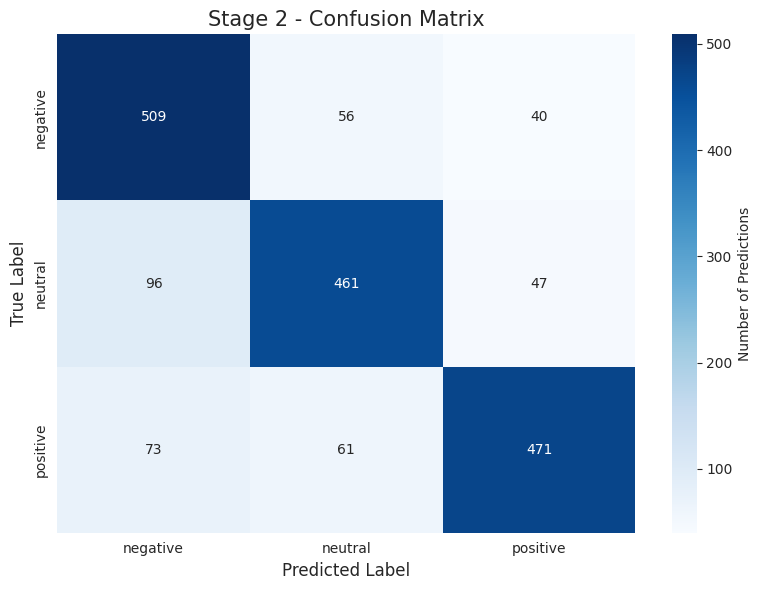

In [10]:
# Get predictions from the trainer
pred_output = trainer.predict(test_data)

# Use compute_metrics function
metrics = compute_metrics(pred_output)

# Predicted label indices
pred_labels = np.argmax(pred_output.predictions, axis=1)

# True label indices
true_labels = pred_output.label_ids

# Convert IDs to text labels
true_text = [id2label[int(x)] for x in true_labels]
pred_text = [id2label[int(x)] for x in pred_labels]

# Overall metrics
print(f"\n✅ Overall Metrics:")
acc = accuracy_score(true_labels, pred_labels)
f1 = f1_score(true_labels, pred_labels, average='weighted')
f1_macro = f1_score(true_labels, pred_labels, average='macro')

# Print metrics
print(f"\n✅ Overall Metrics:")
print(f"   Accuracy:    {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
print(f"   F1-Weighted: {metrics['f1_weighted']:.4f}")
print(f"   F1-Macro:    {metrics['f1_macro']:.4f}")

# Classification report per class
print("\n📊 Classification Report:")
print(classification_report(true_text, pred_text, labels=list(label2id.keys())))

# Confusion matrix
unique_labels = list(id2label.values())
cm = confusion_matrix(true_text, pred_text, labels=unique_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',  # customize color if needed
    xticklabels=unique_labels,
    yticklabels=unique_labels,
    cbar_kws={'label': 'Number of Predictions'}
)
plt.title("Stage 2 - Confusion Matrix", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()

#Save Results & Model

In [11]:

# Prepare results dictionary
results = {
    'stage': 2,
    'method': 'Supervised Learning (Fine-tune on balanced dataset)',
    'dataset': 'Kaggle Game Reviews',
    'dataset_size': len(df),
    'train_size': len(train_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'model': MODEL,
    'epochs': training_args.num_train_epochs,
    'batch_size': training_args.per_device_train_batch_size,
    'learning_rate': training_args.learning_rate,
    'metrics': {
        'accuracy': float(acc),
        'f1_weighted': float(f1),
        'f1_macro': float(f1_macro)
    },
    'class_distribution': df[label_col].value_counts().to_dict(),
    'training_time_seconds': train_result.metrics['train_runtime'],

}

# Save results to JSON
with open('stage2_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("💾 Results saved to: stage2_results.json")

# Save model & tokenizer
model_path = './stage2_roberta_balanced_final'
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print(f"💾 Model saved to: {model_path}")

# Download results JSON from Colab
print("📥 Downloading results...")
files.download('stage2_results.json')

print("\n✅ Stage 2 complete!")

💾 Results saved to: stage2_results.json
💾 Model saved to: ./stage2_roberta_balanced_final
📥 Downloading results...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Stage 2 complete!
